In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
df = pd.read_csv('Офіційний курс гривні щодо іноземних валют.csv')
df

,Дата,Час,Код цифровий,Код літерний,Кількість одиниць,Назва валюти,"Офіційний курс гривні, грн"
0,01.01.2022,0.0,840,USD,1,Долар США,27.2782
1,02.01.2022,0.0,840,USD,1,Долар США,27.2782
2,03.01.2022,0.0,840,USD,1,Долар США,27.2782
3,04.01.2022,0.0,840,USD,1,Долар США,27.2782
4,05.01.2022,0.0,840,USD,1,Долар США,27.2976
...,...,...,...,...,...,...,...
786,26.02.2024,0.0,840,USD,1,Долар США,38.3527
787,27.02.2024,0.0,840,USD,1,Долар США,38.3361
788,28.02.2024,0.0,840,USD,1,Долар США,38.4249
789,29.02.2024,0.0,840,USD,1,Долар США,38.2077


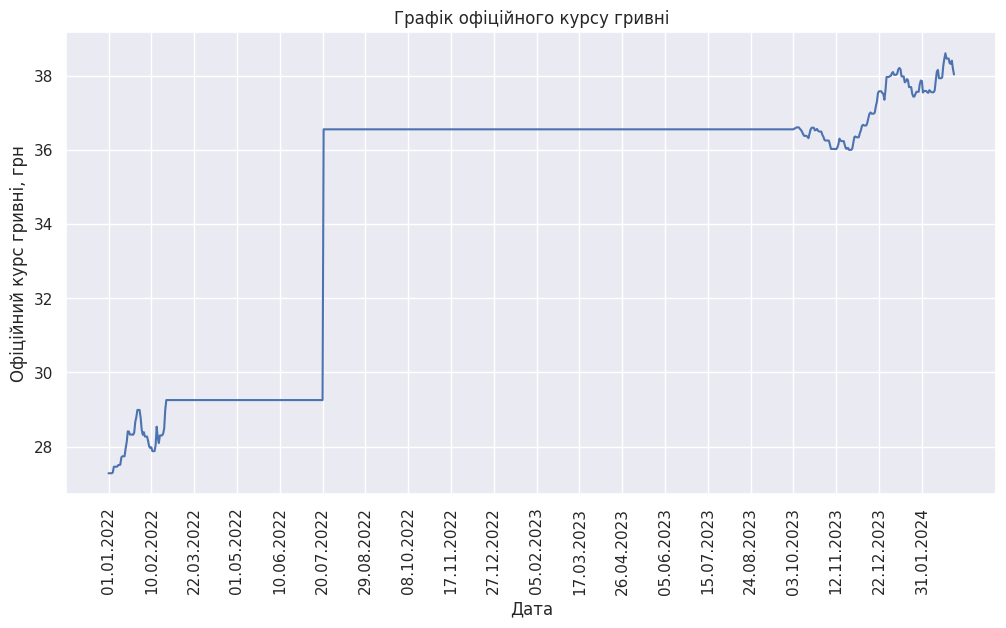

In [35]:
date = df['Дата'].to_numpy()
value = df['Офіційний курс гривні, грн'].to_numpy()
sns.set_theme(style="darkgrid")

plt.figure(figsize=(12, 6))
plt.plot(date, value)
plt.xlabel('Дата')
plt.ylabel('Офіційний курс гривні, грн')
plt.title('Графік офіційного курсу гривні')
plt.xticks(date[::40], rotation=90)
plt.show()

Linear trend: y = 29.80 + 0.01 * x


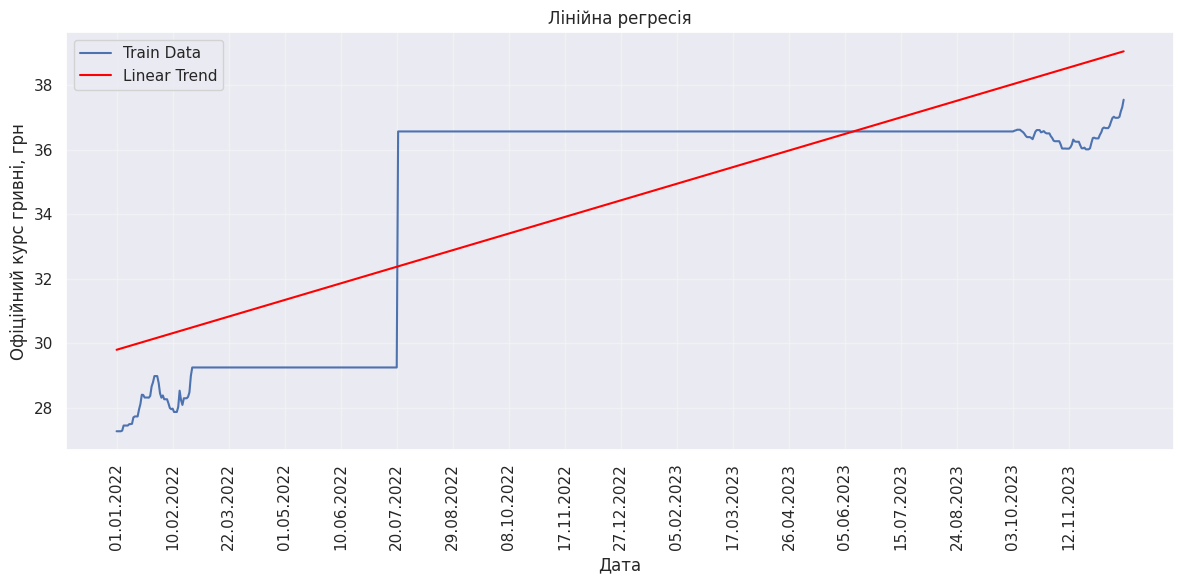

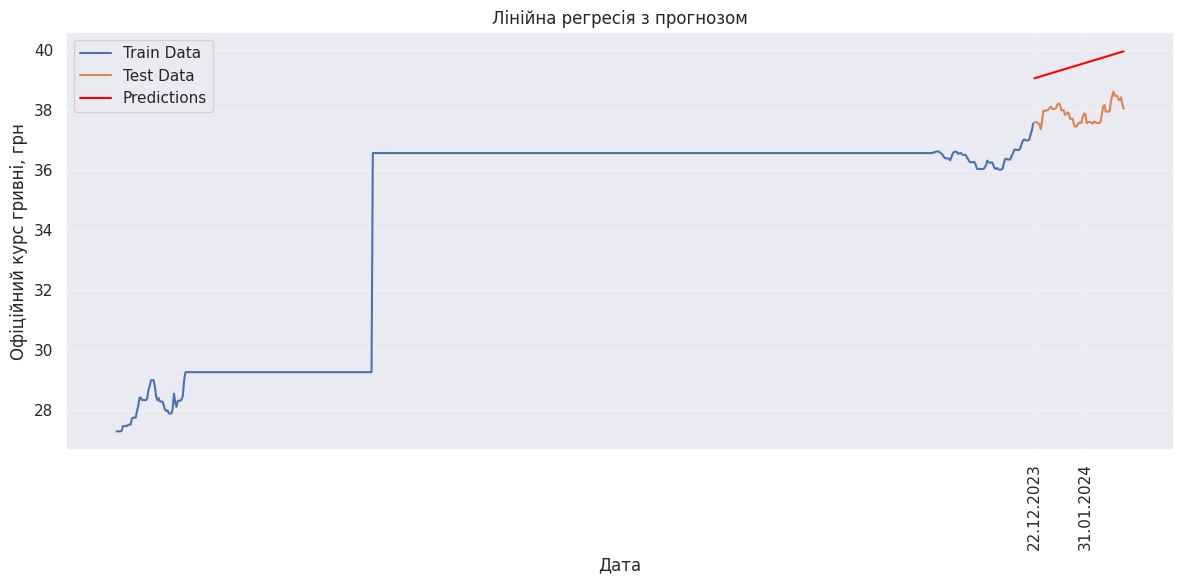

Mean Squared Error (MSE): 2.7530
Root Mean Squared Error (RMSE): 1.6592
Mean Absolute Error (MAE): 1.6274


In [ ]:
train_len = 720
train = df.iloc[:train_len].copy()
test = df.iloc[train_len:].copy()

train_data = train['Офіційний курс гривні, грн'].values
test_data = test['Офіційний курс гривні, грн'].values

def linear_trend(x, y):
    n = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    b = (np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2))
    a = y_mean - b * x_mean

    return a, b

a, b = linear_trend(np.arange(len(train_data)), train_data)
print(f"Linear trend: y = {a:.2f} + {b:.2f} * x")

plt.figure(figsize=(12, 6))
plt.plot(train['Дата'], train_data, label='Train Data')
plt.plot(train['Дата'], a + b * np.arange(len(train_data)), label='Linear Trend', color='red')
plt.xlabel('Дата')
plt.ylabel('Офіційний курс гривні, грн')
plt.title('Лінійна регресія')
plt.xticks(train['Дата'][::40], rotation=90)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

def predict(x, a, b):
    return a + b * x

predictions = predict(np.arange(len(train_data), len(train_data) + len(test_data)), a, b)
plt.figure(figsize=(12, 6))
plt.plot(train['Дата'], train_data, label='Train Data')
plt.plot(test['Дата'], test_data, label='Test Data')
plt.plot(test['Дата'], predictions, label='Predictions', color='red')
plt.xlabel('Дата')
plt.ylabel('Офіційний курс гривні, грн')
plt.title('Лінійна регресія з прогнозом')
plt.xticks(test['Дата'][::40], rotation=90)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

errors = test_data - predictions
mse = np.mean(errors**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(errors))

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

X matrix: [[1.00000e+00 0.00000e+00 0.00000e+00]
 [1.00000e+00 1.00000e+00 1.00000e+00]
 [1.00000e+00 2.00000e+00 4.00000e+00]
 ...
 [1.00000e+00 7.17000e+02 5.14089e+05]
 [1.00000e+00 7.18000e+02 5.15524e+05]
 [1.00000e+00 7.19000e+02 5.16961e+05]] 

XTX matrix: [[7.20000000e+02 2.58840000e+05 1.24156920e+08]
 [2.58840000e+05 1.24156920e+08 6.69981456e+10]
 [1.24156920e+08 6.69981456e+10 3.85641078e+13]] 

XTy matrix: [2.47875386e+04 9.31121249e+06 4.51673930e+09] 

[ 2.61774206e+01  4.31592352e-02 -4.21365210e-05]
26.177420574938836 0.043159235238007014 -4.213652096847858e-05
Квадратична формула: y = 26.18 + 0.04 * x + -0.00 * x^2


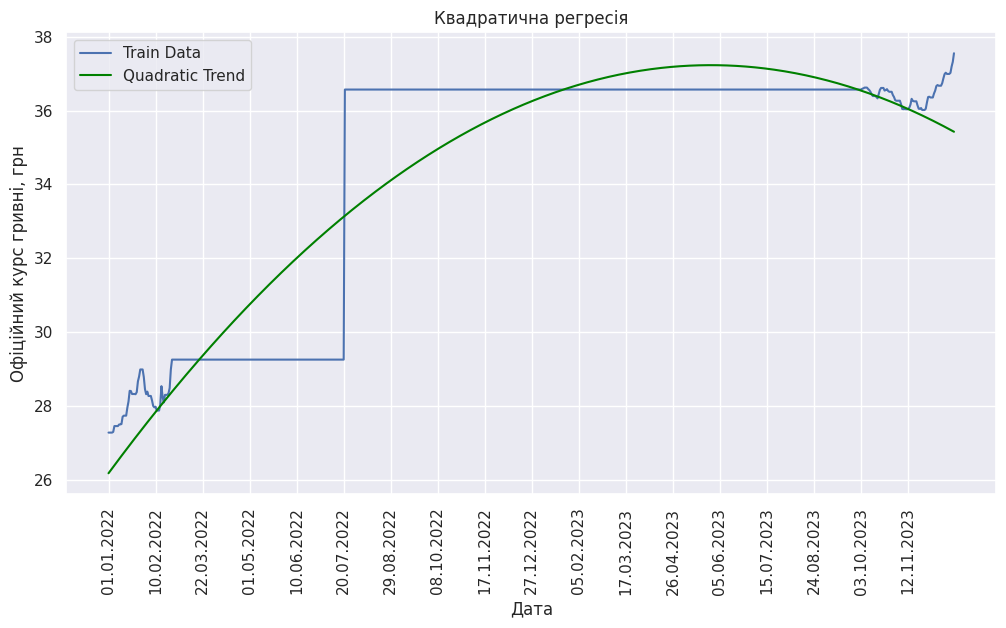

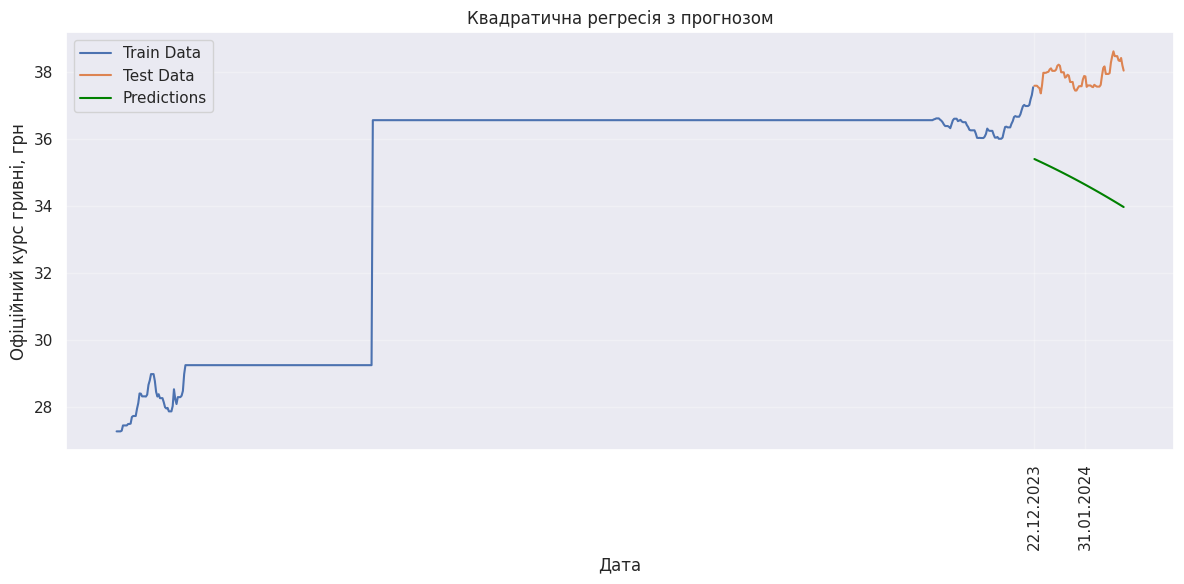

Mean Squared Error (MSE): 10.3584
Root Mean Squared Error (RMSE): 3.2185
Mean Absolute Error (MAE): 3.1610


In [38]:
def gauss_elimination(A, b):
    n = len(b)
    aug = np.column_stack((A, b.reshape(-1, 1)))
    
    for i in range(n):
        max_row = i + np.argmax(abs(aug[i:, i]))
        if max_row != i:
            aug[[i, max_row]] = aug[[max_row, i]]
        
        if abs(aug[i, i]) < 1e-10:
            raise ValueError("Matrix is singular or nearly singular")
        
        for j in range(i + 1, n):
            factor = aug[j, i] / aug[i, i]
            aug[j, i:] -= factor * aug[i, i:]
    
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = aug[i, -1]
        for j in range(i + 1, n):
            x[i] -= aug[i, j] * x[j]
        x[i] /= aug[i, i]
    
    print(x)
    return x

def quadratic_trend(x, y):
    n = len(x)
    X = np.column_stack((np.ones(n), x, x**2))
    print(f"X matrix: {X} \n")
    XTX = X.T @ X
    print(f"XTX matrix: {XTX} \n")
    XTy = X.T @ y
    print(f"XTy matrix: {XTy} \n")
    
    a, b, c  = gauss_elimination(XTX, XTy)
    print(a, b, c)
    return a, b, c

a, b, c = quadratic_trend(np.arange(len(train_data)), train_data)
print(f"Квадратична формула: y = {a:.2f} + {b:.2f} * x + {c:.2f} * x^2")

plt.figure(figsize=(12, 6))
plt.plot(train['Дата'], train_data, label='Train Data')
plt.plot(train['Дата'], a + b * np.arange(len(train_data)) + c * np.arange(len(train_data)) ** 2, label='Quadratic Trend', color='green')
plt.xlabel('Дата')
plt.ylabel('Офіційний курс гривні, грн')
plt.title('Квадратична регресія')
plt.xticks(train['Дата'][::40], rotation=90)
plt.legend()
plt.show()

predictions = a + b * np.arange(len(train_data), len(train_data) + len(test_data)) + c * np.arange(len(train_data), len(train_data) + len(test_data)) ** 2
plt.figure(figsize=(12, 6))
plt.plot(train['Дата'], train_data, label='Train Data')
plt.plot(test['Дата'], test_data, label='Test Data')
plt.plot(test['Дата'], predictions, label='Predictions', color='green')
plt.xlabel('Дата')
plt.ylabel('Офіційний курс гривні, грн')
plt.title('Квадратична регресія з прогнозом')
plt.xticks(test['Дата'][::40], rotation=90)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

errors = test_data - predictions
mse = np.mean(errors**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(errors))
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

